# Figure 4A — Consecutive failures before leaving vs. number of rewards

Recreates Figure 4A from Vertechi et al. for:
- Human subjects (cohort 2, protocol 1, one run per subject)
- Qwen 3.5 without max turns shown (10 games)
- Qwen 3.5 with max turns shown (10 games)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

## 1. Human data — protocol 1, one run per subject

In [2]:
human_summary = pd.read_csv("../human_data/human_cohort2_summary.csv")
print("Summary shape:", human_summary.shape)
print("Columns:", list(human_summary.columns))
human_summary.head()

Summary shape: (14437, 13)
Columns: ['Unnamed: 0', 'subject_id', 'session', 'run', 'protocol', 'streak', 'consec_fail_before_leaving', 'rewards_within_streak', 'pokes_within_streak', 'experimental_group', 'more_than_2_sessions', 'matched', 'experimental_group2']


,Unnamed: 0,subject_id,session,run,protocol,streak,consec_fail_before_leaving,rewards_within_streak,pokes_within_streak,experimental_group,more_than_2_sessions,matched,experimental_group2
0,0,001_R001,1,1,1,1,6,3,12,Remitted,0,1,Remitted
1,1,001_R001,1,1,1,2,12,0,12,Remitted,0,1,Remitted
2,2,001_R001,1,1,1,3,24,0,24,Remitted,0,1,Remitted
3,3,001_R001,1,1,1,4,14,2,16,Remitted,0,1,Remitted
4,4,001_R001,1,1,1,5,10,4,15,Remitted,0,1,Remitted


In [3]:
# Filter to protocol 1 only
h1 = human_summary[human_summary["protocol"] == 1].copy()
print(f"Protocol 1 bouts: {len(h1)}")

# Take only the first run per subject (earliest session, run 1)
h1 = h1.sort_values(["subject_id", "session", "run"])
first_run = h1.groupby("subject_id")[["session", "run"]].first().reset_index()
first_run.columns = ["subject_id", "first_session", "first_run"]

h1 = h1.merge(first_run, on="subject_id")
h1 = h1[(h1["session"] == h1["first_session"]) & (h1["run"] == h1["first_run"])]
h1 = h1.drop(columns=["first_session", "first_run"])

# Drop the last bout per subject (block ends, not a leaving decision)
last_bout_idx = h1.groupby("subject_id")["streak"].idxmax()
h1 = h1.drop(last_bout_idx)

# Note: the summary already uses the correct Vertechi convention
# (strip trailing rewards, count trailing failures, drop all-reward bouts)
# so no further filtering is needed here.

print(f"Unique subjects: {h1['subject_id'].nunique()}")
print(f"Bouts after filtering: {len(h1)}")
h1.head()

Protocol 1 bouts: 8203
Unique subjects: 116
Bouts after filtering: 2203


,Unnamed: 0,subject_id,session,run,protocol,streak,consec_fail_before_leaving,rewards_within_streak,pokes_within_streak,experimental_group,more_than_2_sessions,matched,experimental_group2
0,0,001_R001,1,1,1,1,6,3,12,Remitted,0,1,Remitted
1,1,001_R001,1,1,1,2,12,0,12,Remitted,0,1,Remitted
2,2,001_R001,1,1,1,3,24,0,24,Remitted,0,1,Remitted
3,3,001_R001,1,1,1,4,14,2,16,Remitted,0,1,Remitted
4,4,001_R001,1,1,1,5,10,4,15,Remitted,0,1,Remitted


## 2. LLM data — compute bout-level statistics

In [4]:
def compute_bout_stats(csv_path):
    """Compute bout-level statistics from a single LLM game CSV.
    
    A bout is a sequence of fires at one side, delimited by travel actions.
    
    consec_fail_before_leaving: strip trailing rewards from the bout,
    then count trailing consecutive failures. This matches the Vertechi
    convention — if the agent got a lucky reward right before leaving,
    that reward didn't prevent the leaving decision.
    
    Bouts where every fire was rewarded are dropped (no failure signal).
    The last bout per game is also dropped (game ended, not a leaving decision).
    """
    df = pd.read_csv(csv_path)
    fires = df[df["action"] == "fire"].copy()
    if fires.empty:
        return pd.DataFrame(columns=["rewards_within_streak", "consec_fail_before_leaving"])
    
    # Assign bout IDs: new bout each time the firing side changes
    last_side = None
    bout_id = 0
    bout_ids = []
    for idx, row in fires.iterrows():
        if last_side is not None and row["side"] != last_side:
            bout_id += 1
        last_side = row["side"]
        bout_ids.append(bout_id)
    fires["bout_id"] = bout_ids
    
    bouts = []
    max_bout = fires["bout_id"].max()
    for bid, bout_df in fires.groupby("bout_id"):
        # Skip the last bout — game ended, not a voluntary leaving decision
        if bid == max_bout:
            continue
        rewards = int(bout_df["reward"].sum())
        outcomes = list(bout_df["reward"].values)
        
        # Strip trailing rewards
        while outcomes and outcomes[-1] == 1:
            outcomes.pop()
        # Drop all-reward bouts
        if not outcomes:
            continue
        # Count trailing consecutive failures
        consec_fail = 0
        for v in reversed(outcomes):
            if v == 0:
                consec_fail += 1
            else:
                break
        bouts.append({
            "rewards_within_streak": rewards,
            "consec_fail_before_leaving": consec_fail,
        })
    
    return pd.DataFrame(bouts)

# Test with one file
test = compute_bout_stats("../data/qwen_nomaxturns_batch/qwen-qwen3.5-flash-02-23_protocol-1_20260407_223431_game0.csv")
print("Test bout stats:")
print(test.head(10))
print(f"\nTotal bouts: {len(test)}")

Test bout stats:
   rewards_within_streak  consec_fail_before_leaving
0                      4                           1
1                      1                           1
2                      0                           1
3                      0                           1
4                      0                           2
5                      1                           1
6                      0                           1
7                      2                           3
8                      1                           3
9                      0                           2

Total bouts: 43


In [5]:
def load_llm_batch(batch_dir, label):
    """Load all games from a batch directory and compute bout stats."""
    csv_files = sorted(glob.glob(str(Path(batch_dir) / "*.csv")))
    all_bouts = []
    for i, f in enumerate(csv_files):
        bouts = compute_bout_stats(f)
        bouts["game"] = i
        bouts["label"] = label
        all_bouts.append(bouts)
    return pd.concat(all_bouts, ignore_index=True)

qwen_nomaxturns = load_llm_batch("../data/qwen_nomaxturns_batch", "Qwen 3.5 (no max turns)")
qwen_maxturns = load_llm_batch("../data/qwen_maxturns_batch", "Qwen 3.5 (max turns)")

print(f"No max turns: {len(qwen_nomaxturns)} bouts from {qwen_nomaxturns['game'].nunique()} games")
print(f"Max turns:    {len(qwen_maxturns)} bouts from {qwen_maxturns['game'].nunique()} games")

No max turns: 451 bouts from 10 games
Max turns:    429 bouts from 10 games


## 3. Figure 4A — Consecutive failures before leaving vs. reward number

In [6]:
def compute_mean_and_sem(df, group_col="rewards_within_streak", value_col="consec_fail_before_leaving", subject_col=None):
    """Compute mean and SEM of value_col grouped by group_col.
    
    If subject_col is provided, first average within each subject, then compute SEM across subjects.
    Otherwise, compute SEM across all observations.
    """
    if subject_col:
        # Average within each subject first, then across subjects
        subj_means = df.groupby([subject_col, group_col])[value_col].mean().reset_index()
        grouped = subj_means.groupby(group_col)[value_col]
        mean = grouped.mean()
        sem = grouped.sem()
    else:
        grouped = df.groupby(group_col)[value_col]
        mean = grouped.mean()
        sem = grouped.sem()
    return mean, sem

# Cap reward number for cleaner plot (few bouts with very many rewards)
MAX_REWARDS = 10

h1_plot = h1[h1["rewards_within_streak"] <= MAX_REWARDS]
qnm_plot = qwen_nomaxturns[qwen_nomaxturns["rewards_within_streak"] <= MAX_REWARDS]
qm_plot = qwen_maxturns[qwen_maxturns["rewards_within_streak"] <= MAX_REWARDS]

human_mean, human_sem = compute_mean_and_sem(h1_plot, subject_col="subject_id")
nomaxturns_mean, nomaxturns_sem = compute_mean_and_sem(qnm_plot, subject_col="game")
maxturns_mean, maxturns_sem = compute_mean_and_sem(qm_plot, subject_col="game")

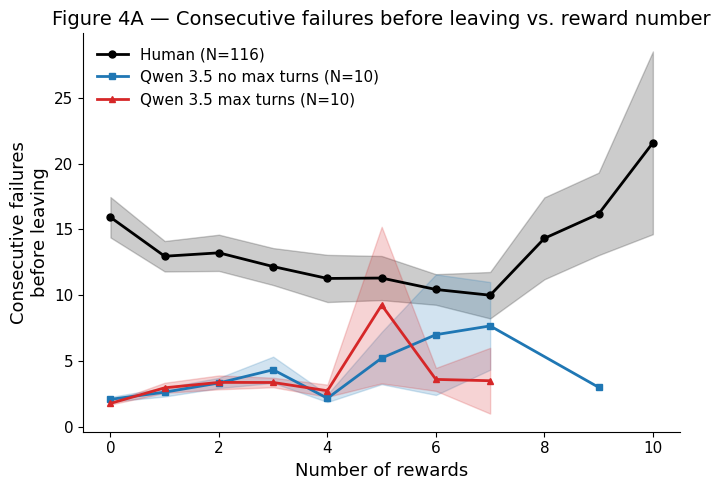

Saved to analysis/figs/figure4a.png


In [7]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Human
ax.plot(human_mean.index, human_mean.values, "o-", color="black", label="Human (N={})".format(h1["subject_id"].nunique()), linewidth=2, markersize=5)
ax.fill_between(human_mean.index, human_mean - human_sem, human_mean + human_sem, alpha=0.2, color="black")

# Qwen no max turns
ax.plot(nomaxturns_mean.index, nomaxturns_mean.values, "s-", color="tab:blue", label="Qwen 3.5 no max turns (N=10)", linewidth=2, markersize=5)
ax.fill_between(nomaxturns_mean.index, nomaxturns_mean - nomaxturns_sem, nomaxturns_mean + nomaxturns_sem, alpha=0.2, color="tab:blue")

# Qwen max turns
ax.plot(maxturns_mean.index, maxturns_mean.values, "^-", color="tab:red", label="Qwen 3.5 max turns (N=10)", linewidth=2, markersize=5)
ax.fill_between(maxturns_mean.index, maxturns_mean - maxturns_sem, maxturns_mean + maxturns_sem, alpha=0.2, color="tab:red")

ax.set_xlabel("Number of rewards", fontsize=13)
ax.set_ylabel("Consecutive failures\nbefore leaving", fontsize=13)
ax.set_title("Figure 4A — Consecutive failures before leaving vs. reward number", fontsize=14)
ax.legend(fontsize=11, frameon=False)
ax.set_xlim(-0.5, MAX_REWARDS + 0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("../analysis/figs/figure4a.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to analysis/figs/figure4a.png")

## 4. Summary statistics

In [8]:
print("=== Bout counts ===")
print(f"Human (protocol 1, 1 run/subject): {len(h1_plot)} bouts from {h1['subject_id'].nunique()} subjects")
print(f"Qwen no max turns: {len(qnm_plot)} bouts from {qwen_nomaxturns['game'].nunique()} games")
print(f"Qwen max turns:    {len(qm_plot)} bouts from {qwen_maxturns['game'].nunique()} games")

print("\n=== Mean consecutive failures before leaving (overall) ===")
print(f"Human:             {h1['consec_fail_before_leaving'].mean():.2f} ± {h1['consec_fail_before_leaving'].sem():.2f}")
print(f"Qwen no max turns: {qwen_nomaxturns['consec_fail_before_leaving'].mean():.2f} ± {qwen_nomaxturns['consec_fail_before_leaving'].sem():.2f}")
print(f"Qwen max turns:    {qwen_maxturns['consec_fail_before_leaving'].mean():.2f} ± {qwen_maxturns['consec_fail_before_leaving'].sem():.2f}")

print("\n=== Slope (regression of consec_fail on reward number) ===")
for name, data in [("Human", h1_plot), ("Qwen no max turns", qnm_plot), ("Qwen max turns", qm_plot)]:
    x = data["rewards_within_streak"].values
    y = data["consec_fail_before_leaving"].values
    slope = np.polyfit(x, y, 1)[0]
    print(f"{name}: slope = {slope:.3f}")

#   - Strip trailing rewards, then count trailing failures
#   - Drop all-reward bouts (no failure signal)
#   - Drop last bout per game/block

=== Bout counts ===
Human (protocol 1, 1 run/subject): 2181 bouts from 116 subjects
Qwen no max turns: 451 bouts from 10 games
Qwen max turns:    427 bouts from 10 games

=== Mean consecutive failures before leaving (overall) ===
Human:             11.43 ± 0.32
Qwen no max turns: 2.47 ± 0.13
Qwen max turns:    2.34 ± 0.10

=== Slope (regression of consec_fail on reward number) ===
Human: slope = 0.181
Qwen no max turns: slope = 0.509
Qwen max turns: slope = 0.566
